In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

In [6]:
from pathlib import Path

list(Path("../../data/raw/solar").glob("*.csv"))

[]

In [7]:
from pathlib import Path

Path.cwd()

WindowsPath('c:/Projects/SolarDrought/notebooks')

In [8]:
list(Path("../data/raw/solar").glob("*.csv"))

[WindowsPath('../data/raw/solar/b7bc5a9a6b8db8501fc3907545fa2d4c.csv')]

In [9]:
data_path = Path("../data/raw/solar/b7bc5a9a6b8db8501fc3907545fa2d4c.csv")

In [10]:
data_path.exists()

True

In [11]:
df = pd.read_csv(
    data_path,
    sep=";",
    comment="#",
    header=None,
    names=[
        "observation_period",
        "toa",
        "clear_sky_ghi",
        "clear_sky_bhi",
        "clear_sky_dhi",
        "clear_sky_bni",
        "ghi",
        "bhi",
        "dhi",
        "bni",
        "reliability",
    ],
)

In [12]:
df.head()

,observation_period,toa,clear_sky_ghi,clear_sky_bhi,clear_sky_dhi,clear_sky_bni,ghi,bhi,dhi,bni,reliability
0,2020-01-01T00:00:00.0/2020-01-01T01:00:00.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2020-01-01T01:00:00.0/2020-01-01T02:00:00.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2020-01-01T02:00:00.0/2020-01-01T03:00:00.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2020-01-01T03:00:00.0/2020-01-01T04:00:00.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2020-01-01T04:00:00.0/2020-01-01T05:00:00.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [13]:
df.shape

(744, 11)

In [14]:
df.columns

Index(['observation_period', 'toa', 'clear_sky_ghi', 'clear_sky_bhi',
       'clear_sky_dhi', 'clear_sky_bni', 'ghi', 'bhi', 'dhi', 'bni',
       'reliability'],
      dtype='object')

In [15]:
df.isna().sum()

observation_period    0
toa                   0
clear_sky_ghi         0
clear_sky_bhi         0
clear_sky_dhi         0
clear_sky_bni         0
ghi                   0
bhi                   0
dhi                   0
bni                   0
reliability           0
dtype: int64

In [16]:
df.dtypes

observation_period     object
toa                   float64
clear_sky_ghi         float64
clear_sky_bhi         float64
clear_sky_dhi         float64
clear_sky_bni         float64
ghi                   float64
bhi                   float64
dhi                   float64
bni                   float64
reliability           float64
dtype: object

In [17]:
df["observation_period"].nunique()

744

In [18]:
df["reliability"].describe()

count    744.000000
mean       0.976086
std        0.076540
min        0.650000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: reliability, dtype: float64

In [19]:
df["reliability"].value_counts().sort_index()

reliability
0.6500      2
0.6583      2
0.6667      3
0.6750      3
0.6833      4
0.6917      7
0.7000      3
0.7083      1
0.7167      7
0.7250      2
0.7333      3
0.7417      1
0.7500      3
0.7583      2
0.7667      2
0.7750      1
0.7833     11
0.7917      1
0.8000      1
0.8083      1
0.8417      2
0.8583      1
0.8833      1
0.8917      1
0.9000      1
0.9167      1
0.9250      1
0.9417      2
0.9500      2
0.9583      1
0.9667      1
0.9750      1
0.9833      3
0.9917      1
1.0000    665
Name: count, dtype: int64

In [20]:
df[[
    "toa",
    "clear_sky_ghi",
    "ghi",
    "clear_sky_bhi",
    "bhi",
    "clear_sky_dhi",
    "dhi",
    "clear_sky_bni",
    "bni"
]].describe()

,toa,clear_sky_ghi,ghi,clear_sky_bhi,bhi,clear_sky_dhi,dhi,clear_sky_bni,bni
count,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000
mean,128.989587,95.074905,74.815036,77.441961,53.235978,17.632944,21.579056,273.740501,191.227050
std,195.306948,148.932053,127.782691,124.646315,105.672851,26.358612,36.081893,383.070519,334.861590
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,266.200700,181.933175,102.043450,138.797325,24.155725,39.600900,42.196275,732.248575,280.268625
max,606.571100,479.115400,457.186400,419.400800,397.587000,121.404800,234.221900,1021.574300,1021.574300


In [21]:
(df["ghi"] == 0).sum()

np.int64(448)

In [22]:
(df["ghi"] > 0).sum()

np.int64(296)

In [23]:
(df["ghi"] == 0).sum(), (df["clear_sky_ghi"] == 0).sum()

(np.int64(448), np.int64(448))

In [24]:
((df["clear_sky_ghi"] == 0) & (df["ghi"] > 0)).sum()

np.int64(0)

In [25]:
(df["ghi"] > df["clear_sky_ghi"]).sum()

np.int64(0)

In [26]:
(df["ghi"] == df["clear_sky_ghi"]).sum()

np.int64(623)

In [27]:
# ============================================
# SOLARDROUGHT — BASIC DATA QUALITY CHECK
# CAMS January 2020 pilot dataset
# ============================================

print("===== DATASET STRUCTURE =====")
print("Shape:", df.shape)
print("Rows:", len(df))
print("Columns:", len(df.columns))
print()

print("===== COLUMN NAMES =====")
print(df.columns.tolist())
print()

print("===== DATA TYPES =====")
print(df.dtypes)
print()

print("===== MISSING VALUES =====")
print(df.isna().sum())
print()

print("===== DUPLICATE ROWS =====")
print("Duplicate rows:", df.duplicated().sum())
print()

print("===== UNIQUE OBSERVATION PERIODS =====")
print("Unique periods:", df["observation_period"].nunique())
print()

print("===== GHI COUNTS =====")
print("GHI = 0:", (df["ghi"] == 0).sum())
print("GHI > 0:", (df["ghi"] > 0).sum())
print("GHI < 0:", (df["ghi"] < 0).sum())
print()

print("===== CLEAR-SKY GHI COUNTS =====")
print("Clear-sky GHI = 0:", (df["clear_sky_ghi"] == 0).sum())
print("Clear-sky GHI > 0:", (df["clear_sky_ghi"] > 0).sum())
print("Clear-sky GHI < 0:", (df["clear_sky_ghi"] < 0).sum())
print()

print("===== GHI vs CLEAR-SKY GHI =====")
print("GHI > clear-sky GHI:",
      (df["ghi"] > df["clear_sky_ghi"]).sum())

print("GHI = clear-sky GHI:",
      (df["ghi"] == df["clear_sky_ghi"]).sum())

print("GHI < clear-sky GHI:",
      (df["ghi"] < df["clear_sky_ghi"]).sum())

print()

print("===== ZERO CLEAR-SKY / POSITIVE GHI CHECK =====")
print(
    "Clear-sky GHI = 0 AND GHI > 0:",
    ((df["clear_sky_ghi"] == 0) & (df["ghi"] > 0)).sum()
)
print()

print("===== DAYLIGHT EQUALITY CHECK =====")
print(
    "GHI = clear-sky GHI AND clear-sky GHI > 0:",
    ((df["ghi"] == df["clear_sky_ghi"]) &
     (df["clear_sky_ghi"] > 0)).sum()
)
print()

print("===== RELIABILITY =====")
print(df["reliability"].describe())
print()

print("Reliability < 1.0:",
      (df["reliability"] < 1.0).sum())

print("Reliability = 1.0:",
      (df["reliability"] == 1.0).sum())
print()

print("===== NEGATIVE VALUES =====")
numeric_columns = df.select_dtypes(include=np.number).columns

negative_counts = (df[numeric_columns] < 0).sum()

print(negative_counts)
print()

print("===== SOLAR VARIABLE SUMMARY =====")
print(
    df[
        [
            "toa",
            "clear_sky_ghi",
            "ghi",
            "clear_sky_bhi",
            "bhi",
            "clear_sky_dhi",
            "dhi",
            "clear_sky_bni",
            "bni",
        ]
    ].describe()
)

===== DATASET STRUCTURE =====
Shape: (744, 11)
Rows: 744
Columns: 11

===== COLUMN NAMES =====
['observation_period', 'toa', 'clear_sky_ghi', 'clear_sky_bhi', 'clear_sky_dhi', 'clear_sky_bni', 'ghi', 'bhi', 'dhi', 'bni', 'reliability']

===== DATA TYPES =====
observation_period     object
toa                   float64
clear_sky_ghi         float64
clear_sky_bhi         float64
clear_sky_dhi         float64
clear_sky_bni         float64
ghi                   float64
bhi                   float64
dhi                   float64
bni                   float64
reliability           float64
dtype: object

===== MISSING VALUES =====
observation_period    0
toa                   0
clear_sky_ghi         0
clear_sky_bhi         0
clear_sky_dhi         0
clear_sky_bni         0
ghi                   0
bhi                   0
dhi                   0
bni                   0
reliability           0
dtype: int64

===== DUPLICATE ROWS =====
Duplicate rows: 0

===== UNIQUE OBSERVATION PERIODS =====
Uniqu

In [28]:
print("First observation:")
print(df["observation_period"].iloc[0])

print("\nLast observation:")
print(df["observation_period"].iloc[-1])

First observation:
2020-01-01T00:00:00.0/2020-01-01T01:00:00.0

Last observation:
2020-01-31T23:00:00.0/2020-02-01T00:00:00.0


In [29]:
periods = df["observation_period"].str.split("/", expand=True)

start_times = pd.to_datetime(periods[0])
end_times = pd.to_datetime(periods[1])

gaps = start_times.iloc[1:].reset_index(drop=True) != end_times.iloc[:-1].reset_index(drop=True)

print("Number of gaps/overlaps:", gaps.sum())

Number of gaps/overlaps: 0


In [30]:
duration_hours = (end_times - start_times).dt.total_seconds() / 3600

print("Unique interval durations:")
print(duration_hours.value_counts().sort_index())

print("\nAny interval not equal to 1 hour:",
      (duration_hours != 1).sum())

Unique interval durations:
1.0    744
Name: count, dtype: int64

Any interval not equal to 1 hour: 0


In [31]:
df["observation_period"].iloc[5:15]

5     2020-01-01T05:00:00.0/2020-01-01T06:00:00.0
6     2020-01-01T06:00:00.0/2020-01-01T07:00:00.0
7     2020-01-01T07:00:00.0/2020-01-01T08:00:00.0
8     2020-01-01T08:00:00.0/2020-01-01T09:00:00.0
9     2020-01-01T09:00:00.0/2020-01-01T10:00:00.0
10    2020-01-01T10:00:00.0/2020-01-01T11:00:00.0
11    2020-01-01T11:00:00.0/2020-01-01T12:00:00.0
12    2020-01-01T12:00:00.0/2020-01-01T13:00:00.0
13    2020-01-01T13:00:00.0/2020-01-01T14:00:00.0
14    2020-01-01T14:00:00.0/2020-01-01T15:00:00.0
Name: observation_period, dtype: object

In [32]:
df["observation_period"]

0      2020-01-01T00:00:00.0/2020-01-01T01:00:00.0
1      2020-01-01T01:00:00.0/2020-01-01T02:00:00.0
2      2020-01-01T02:00:00.0/2020-01-01T03:00:00.0
3      2020-01-01T03:00:00.0/2020-01-01T04:00:00.0
4      2020-01-01T04:00:00.0/2020-01-01T05:00:00.0
                          ...                     
739    2020-01-31T19:00:00.0/2020-01-31T20:00:00.0
740    2020-01-31T20:00:00.0/2020-01-31T21:00:00.0
741    2020-01-31T21:00:00.0/2020-01-31T22:00:00.0
742    2020-01-31T22:00:00.0/2020-01-31T23:00:00.0
743    2020-01-31T23:00:00.0/2020-02-01T00:00:00.0
Name: observation_period, Length: 744, dtype: object

In [33]:
df["timestamp"] = pd.to_datetime(
    df["observation_period"].str.split("/").str[0]
)

In [34]:
df[["observation_period", "timestamp"]].head(10)

,observation_period,timestamp
0,2020-01-01T00:00:00.0/2020-01-01T01:00:00.0,2020-01-01 00:00:00
1,2020-01-01T01:00:00.0/2020-01-01T02:00:00.0,2020-01-01 01:00:00
2,2020-01-01T02:00:00.0/2020-01-01T03:00:00.0,2020-01-01 02:00:00
3,2020-01-01T03:00:00.0/2020-01-01T04:00:00.0,2020-01-01 03:00:00
4,2020-01-01T04:00:00.0/2020-01-01T05:00:00.0,2020-01-01 04:00:00
5,2020-01-01T05:00:00.0/2020-01-01T06:00:00.0,2020-01-01 05:00:00
6,2020-01-01T06:00:00.0/2020-01-01T07:00:00.0,2020-01-01 06:00:00
7,2020-01-01T07:00:00.0/2020-01-01T08:00:00.0,2020-01-01 07:00:00
8,2020-01-01T08:00:00.0/2020-01-01T09:00:00.0,2020-01-01 08:00:00
9,2020-01-01T09:00:00.0/2020-01-01T10:00:00.0,2020-01-01 09:00:00


In [35]:
# Check timestamp integrity

print("Duplicate timestamps:", df["timestamp"].duplicated().sum())

time_differences = df["timestamp"].diff().dropna()

print("\nUnique time differences:")
print(time_differences.value_counts())

print("\nExpected hourly intervals:",
      (time_differences == pd.Timedelta(hours=1)).sum())

print("Unexpected intervals:",
      (time_differences != pd.Timedelta(hours=1)).sum())

print("\nTimestamp range:")
print("Start:", df["timestamp"].min())
print("End:", df["timestamp"].max())

Duplicate timestamps: 0

Unique time differences:
timestamp
0 days 01:00:00    743
Name: count, dtype: int64

Expected hourly intervals: 743
Unexpected intervals: 0

Timestamp range:
Start: 2020-01-01 00:00:00
End: 2020-01-31 23:00:00


In [36]:
# Daylight vs nighttime diagnostic

daylight_mask = df["clear_sky_ghi"] > 0
night_mask = df["clear_sky_ghi"] == 0

print("Total observations:", len(df))

print("\nBased on clear-sky GHI:")
print("Daylight observations:", daylight_mask.sum())
print("Nighttime observations:", night_mask.sum())

print("\nObserved GHI during daylight:")
print("Minimum:", df.loc[daylight_mask, "ghi"].min())
print("Maximum:", df.loc[daylight_mask, "ghi"].max())
print("Mean:", df.loc[daylight_mask, "ghi"].mean())

print("\nObserved GHI during nighttime:")
print("Unique GHI values:")
print(df.loc[night_mask, "ghi"].unique())

print("\nAny positive GHI during clear-sky nighttime:",
      (df.loc[night_mask, "ghi"] > 0).sum())

Total observations: 744

Based on clear-sky GHI:
Daylight observations: 296
Nighttime observations: 448

Observed GHI during daylight:
Minimum: 0.0052
Maximum: 457.1864
Mean: 188.04860371621623

Observed GHI during nighttime:
Unique GHI values:
[0.]

Any positive GHI during clear-sky nighttime: 0


In [37]:
# Observed vs clear-sky GHI diagnostic

daylight_df = df[df["clear_sky_ghi"] > 0].copy()

daylight_df["ghi_difference"] = (
    daylight_df["ghi"] - daylight_df["clear_sky_ghi"]
)

daylight_df["ghi_ratio"] = (
    daylight_df["ghi"] / daylight_df["clear_sky_ghi"]
)

print("Daylight observations:", len(daylight_df))

print("\nObserved - Clear-sky GHI:")
print(daylight_df["ghi_difference"].describe())

print("\nObserved / Clear-sky GHI:")
print(daylight_df["ghi_ratio"].describe())

print("\nRatio outside physical range [0, 1]:")
print(
    (
        (daylight_df["ghi_ratio"] < 0) |
        (daylight_df["ghi_ratio"] > 1)
    ).sum()
)

print("\nNumber of exact observed = clear-sky values:")
print(
    (
        daylight_df["ghi"] == daylight_df["clear_sky_ghi"]
    ).sum()
)

Daylight observations: 296

Observed - Clear-sky GHI:
count    296.000000
mean     -50.923456
std       94.679181
min     -404.397100
25%      -51.473125
50%        0.000000
75%        0.000000
max        0.000000
Name: ghi_difference, dtype: float64

Observed / Clear-sky GHI:
count    296.000000
mean       0.803429
std        0.293146
min        0.111461
25%        0.644869
50%        1.000000
75%        1.000000
max        1.000000
Name: ghi_ratio, dtype: float64

Ratio outside physical range [0, 1]:
0

Number of exact observed = clear-sky values:
175


In [38]:
# Create daylight-only clear-sky index

df["csi"] = np.nan

daylight_mask = df["clear_sky_ghi"] > 0

df.loc[daylight_mask, "csi"] = (
    df.loc[daylight_mask, "ghi"]
    / df.loc[daylight_mask, "clear_sky_ghi"]
)

print("CSI missing values:", df["csi"].isna().sum())

print("\nCSI statistics:")
print(df["csi"].describe())

print("\nNighttime CSI values:")
print(df.loc[~daylight_mask, "csi"].unique())

print("\nCSI outside [0, 1]:")
print(
    (
        (df["csi"] < 0) |
        (df["csi"] > 1)
    ).sum()
)

CSI missing values: 448

CSI statistics:
count    296.000000
mean       0.803429
std        0.293146
min        0.111461
25%        0.644869
50%        1.000000
75%        1.000000
max        1.000000
Name: csi, dtype: float64

Nighttime CSI values:
[nan]

CSI outside [0, 1]:
0


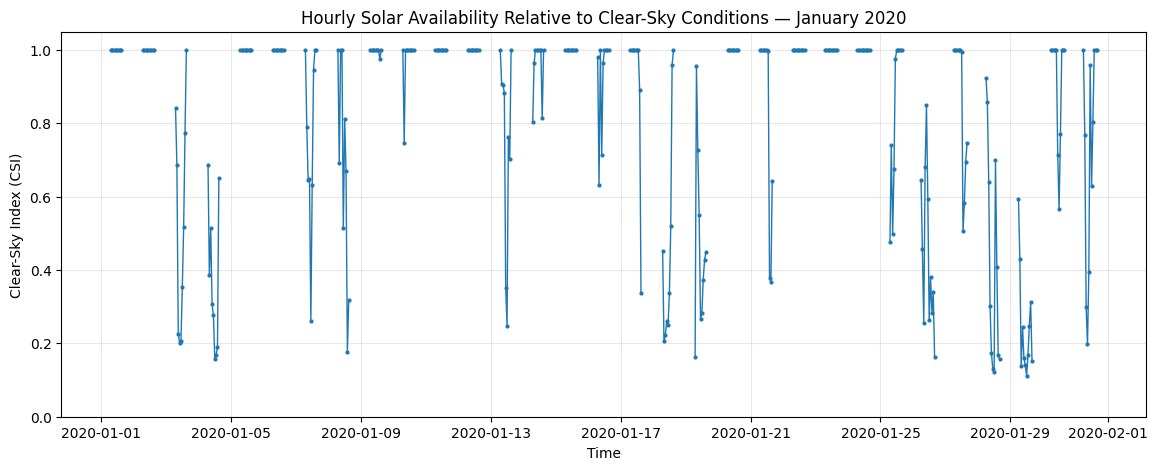

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    df["timestamp"],
    df["csi"],
    marker="o",
    markersize=2,
    linewidth=1
)

plt.xlabel("Time")
plt.ylabel("Clear-Sky Index (CSI)")
plt.title("Hourly Solar Availability Relative to Clear-Sky Conditions — January 2020")

plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)

plt.show()

In [40]:
# CSI distribution

csi_values = df["csi"].dropna()

print("Number of daylight CSI observations:", len(csi_values))

print("\nSelected CSI percentiles:")
print(
    csi_values.quantile(
        [0.01, 0.05, 0.10, 0.20, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nNumber of CSI observations in selected ranges:")

bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

print(
    pd.cut(
        csi_values,
        bins=bins,
        include_lowest=True
    ).value_counts().sort_index()
)

Number of daylight CSI observations: 296

Selected CSI percentiles:
0.01    0.137729
0.05    0.175853
0.10    0.263017
0.20    0.505582
0.25    0.644869
0.50    1.000000
0.75    1.000000
0.90    1.000000
0.95    1.000000
0.99    1.000000
Name: csi, dtype: float64

Number of CSI observations in selected ranges:
csi
(-0.001, 0.2]     18
(0.2, 0.4]        33
(0.4, 0.6]        18
(0.6, 0.8]        29
(0.8, 1.0]       198
Name: count, dtype: int64


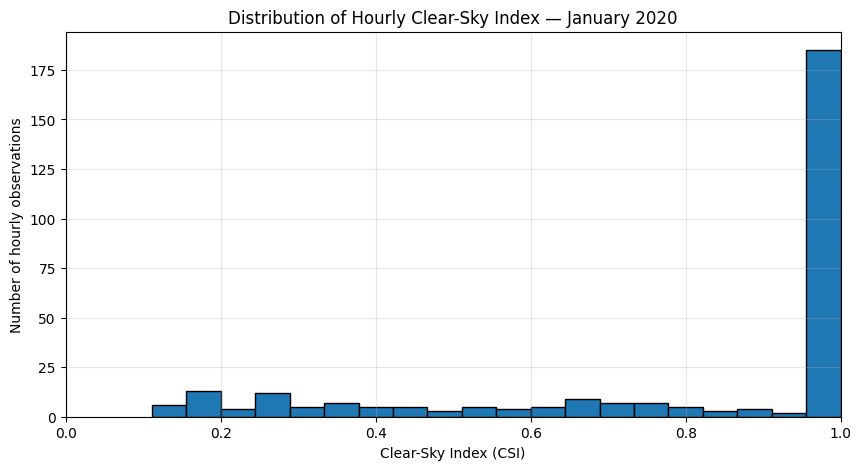

In [41]:
plt.figure(figsize=(10, 5))

plt.hist(
    csi_values,
    bins=20,
    edgecolor="black"
)

plt.xlabel("Clear-Sky Index (CSI)")
plt.ylabel("Number of hourly observations")
plt.title("Distribution of Hourly Clear-Sky Index — January 2020")

plt.xlim(0, 1)
plt.grid(True, alpha=0.3)

plt.show()

In [42]:
# Detailed CSI distribution diagnostics

csi_values = df["csi"].dropna()

print("===== CSI DISTRIBUTION =====")

print("\nNumber of daylight observations:", len(csi_values))

print("\nPercentiles:")
print(
    csi_values.quantile(
        [0.01, 0.05, 0.10, 0.20, 0.25,
         0.50, 0.75, 0.80, 0.90, 0.95, 0.99]
    )
)

print("\nExact CSI = 1:")
print((csi_values == 1.0).sum())

print(
    "Percentage exactly 1:",
    (csi_values == 1.0).mean() * 100
)

print("\nCSI < selected thresholds:")

for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    count = (csi_values < threshold).sum()
    percentage = (csi_values < threshold).mean() * 100

    print(
        f"CSI < {threshold:.1f}: "
        f"{count} observations ({percentage:.2f}%)"
    )

print("\nCSI range counts:")

bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

range_counts = pd.cut(
    csi_values,
    bins=bins,
    include_lowest=True
).value_counts().sort_index()

print(range_counts)

===== CSI DISTRIBUTION =====

Number of daylight observations: 296

Percentiles:
0.01    0.137729
0.05    0.175853
0.10    0.263017
0.20    0.505582
0.25    0.644869
0.50    1.000000
0.75    1.000000
0.80    1.000000
0.90    1.000000
0.95    1.000000
0.99    1.000000
Name: csi, dtype: float64

Exact CSI = 1:
175
Percentage exactly 1: 59.12162162162162

CSI < selected thresholds:
CSI < 0.2: 18 observations (6.08%)
CSI < 0.3: 36 observations (12.16%)
CSI < 0.4: 51 observations (17.23%)
CSI < 0.5: 59 observations (19.93%)
CSI < 0.6: 69 observations (23.31%)
CSI < 0.7: 85 observations (28.72%)
CSI < 0.8: 98 observations (33.11%)

CSI range counts:
csi
(-0.001, 0.2]     18
(0.2, 0.4]        33
(0.4, 0.6]        18
(0.6, 0.8]        29
(0.8, 1.0]       198
Name: count, dtype: int64
